2.11.0+cu128
cuda


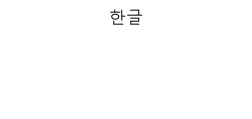

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(torch.__version__)
print(device)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [2]:
# # DQN (Deep Q-Network)
# # 자전거 타기를 이용한 강화학습 기본 개념
# mastered_bicycle = False

# def try_pedaling():
#     import random
#     return random.choice(["왼발", "오른발"])

# def stayed_balanced(): # 핸들을 조정하면서 균형을 잡는
#     import random
#     return random.random() > 0.3

# def update_strategy(action, reward): # 전략 갱신
#     pass

# while not mastered_bicycle:
#     action = try_pedaling()
#     balanced = stayed_balanced()

#     if balanced:
#         reward = +10
#         print("good job")
#     else:
#         reward = -5
#         print("try again")
#     update_strategy(action, reward)

#     import random
#     if random.random() > 0.95:
#         mastered_bicycle = True
# print("success")

In [3]:
# 강화학습 5대 중요 키워드
# 정책을 세우는것이 학습의 최종 목표
# 로봇관련 무언가를 하게되면 반드시 필요함

# class ReinforcementLearningDemo():
#     def __init__(self):
#         self.score = 0
#         self.game_over = False

#     def cartpole_example(self):
#         print("목표 : 막대 쓰러지지 않기")
#         while not self.game_over:
#             state = {"pole_angle" : 0.1,
#                      "cart_position" : 0.0,
#                      "pole_velocity" : 0.02,
#                      "cart_velocity" : 0.1}
#             print(state)
#             action = self.choose_action(state)
#             print(f"선택한 행동 {"왼쪽" if action == -1 else "오른쪽"}")
#             reward = self.calculate_reward(state, action)
#             print(f"받은 보상 {reward}")
#             self.update_policy(state, action, reward)
#             print("전략 업데이트")
#             self.score += reward
#             if self.score < -100:
#                 self.game_over = True
#         print(f"최종 스코어 {self.score}")

#     def choose_action(self, state):
#         import random

#         if random.random() < 0.9:
#             return 1 if state["pole_angle"] > 0 else -1
#         else:
#             return random.choice([-1, 1])

#     def calculate_reward(self, state, action):
#         if abs(state["pole_angle"]) > 0.5:
#             return -100
#         else:
#             return +1

#     def update_policy(self, state, action, reward):
#         learning_rate = 0.1
#         discount_factor = 0.95
#         print("더 나은 전략으로 업데이트")

# demo = ReinforcementLearningDemo()
# demo.cartpole_example()

# 무한루프 가능성으로 전체 주석

In [ ]:
# Q-Net

import gymnasium as gym # 강화학습을 할 환경
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque

class QNetWork(nn.Module): # 다층 퍼셉트론과 모양이 동일함
    def __init__(self,
                 state_size,
                 action_size,
                 seed,
                 fc1_units = 64,
                 fc2_units = 64):
        super(QNetWork, self).__init__()
        self.seed = torch.manual_seed(seed)
        self.fc1 = nn.Linear(state_size, fc1_units)
        self.fc2 = nn.Linear(fc1_units, fc2_units)
        self.fc3 = nn.Linear(fc2_units, action_size)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
seed = 42
qnetwork_local = QNetWork(state_size, action_size, seed)
qnetwork_target = QNetWork(state_size, action_size, seed)
optimizer = optim.Adam(qnetwork_local.parameters(), lr = 5e-4)

buffer_size = int(1e5)
batch_size = 64
memory = deque(maxlen = buffer_size)

def step(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

def sample():
    experiences = random.sample(memory, k = batch_size)
    states = torch.from_numpy(np.vstack([e[0] for e in experiences])).float()
    actions = torch.from_numpy(np.vstack([e[1] for e in experiences])).long()
    rewards = torch.from_numpy(np.vstack([e[2] for e in experiences])).float()
    next_states = torch.from_numpy(np.vstack([e[3] for e in experiences])).float()
    dones = torch.from_numpy(np.vstack([e[4] for e in experiences]).astype(np.uint8)).float()
    return (states, actions, rewards, next_states, dones)

def learn(experiences, gamma):
    states, actions, rewards, next_states, dones = experiences
    Q_targets_next = qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)
    Q_targets = rewards + (gamma * Q_targets_next * (1 - dones))
    Q_expected = qnetwork_local(states).gather(1, actions)
    loss = nn.MSELoss()(Q_expected, Q_targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

gamma = 0.99
tau = 1e-3
n_episodes = 200
max_t = 1000

for i_episode in range(1, n_episodes + 1):
    state, info = env.reset()
    total_reward = 0
    for t in range(max_t):
        state_tensor = torch.from_numpy(state).float().unsqueeze(0)
        with torch.no_grad():
            action_values = qnetwork_local(state_tensor)
        action = np.argmax(action_values.cpu().data.numpy())
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step(state, action, reward, next_state, done)
        total_reward += reward
        if len(memory) > batch_size:
            experiences = sample()
            loss = learn(experiences, gamma)
        state = next_state
        if done:
            break
    for target_param, local_param in zip(qnetwork_target.parameters(),
                                         qnetwork_local.parameters()):
        target_param.data.copy_(tau * local_param.data + (1 - tau) * target_param.data)
    print(i_episode, total_reward) # 강화 학습의 종료시점

env.close()

1 10.0
2 9.0
3 8.0
4 9.0
5 10.0
6 9.0
7 9.0
8 8.0
9 8.0
10 9.0
11 11.0
12 9.0
13 9.0
14 10.0
15 10.0
16 9.0
17 10.0
18 9.0
19 10.0
20 8.0
21 8.0
22 8.0
23 9.0
24 10.0
25 10.0
26 8.0
27 9.0
28 8.0
29 9.0
30 10.0
31 9.0
32 10.0
33 10.0
34 10.0
35 9.0
36 9.0
37 9.0
38 10.0
39 8.0
40 9.0
41 9.0
42 9.0
43 9.0
44 10.0
45 10.0
46 10.0
47 10.0
48 10.0
49 10.0
50 10.0
51 8.0
52 8.0
53 9.0
54 9.0
55 9.0
56 10.0
57 10.0
58 10.0
59 9.0
60 10.0
61 10.0
62 10.0
63 9.0
64 10.0
65 9.0
66 9.0
67 10.0
68 9.0
69 9.0
70 9.0
71 8.0
72 8.0
73 9.0
74 8.0
75 10.0
76 9.0
77 8.0
78 11.0
79 10.0
80 10.0
81 10.0
82 9.0
83 9.0
84 10.0
85 10.0
86 9.0
87 9.0
88 9.0
89 8.0
90 10.0
91 10.0
92 10.0
93 10.0
94 10.0
95 10.0
96 10.0
97 9.0
98 10.0
99 9.0
100 9.0
101 9.0
102 9.0
103 10.0
104 11.0
105 9.0
106 10.0
107 9.0
108 8.0
109 9.0
110 11.0
111 9.0
112 9.0
113 9.0
114 10.0
115 10.0
116 9.0
117 8.0
118 9.0
119 10.0
120 10.0
121 9.0
122 10.0
123 10.0
124 10.0
125 9.0
126 10.0
127 9.0
128 9.0
129 8.0
130 9.0
131 10.0
132

In [9]:
# 강화 학습은 잘 안됨, seed만 바꾸면 흔들리게됨

import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

class PolicyNetWork(nn.Module):
    def __init__(self,
                 state_size,
                 action_size,
                 hidden_dim = 128):
        super(PolicyNetWork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_size)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = self.fc2(x)
        return torch.softmax(x, dim = -1)

env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

policy_net = PolicyNetWork(state_size, action_size)
optimizer = optim.Adam(policy_net.parameters(), lr = 0.01)

def select_action(state):
    state = torch.from_numpy(state).float().unsqueeze(0)
    probs = policy_net(state)
    action = torch.multinomial(probs, num_samples = 1)
    return action.item(), torch.log(probs[0, action.item()])

def reinforce_update(episode_rewards, episode_log_probs, gamma = 0.99):
    R = 0
    returns = []
    for r in episode_rewards[::-1]:
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    loss = 0
    for log_prob, R in zip(episode_log_probs, returns):
        loss -= log_prob * R
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

num_episodes = 1000
for episode in range(num_episodes):
    state, info = env.reset()
    episode_rewards = []
    episode_log_probs = []
    done = False
    while not done:
        action, log_prob = select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_rewards.append(reward)
        episode_log_probs.append(log_prob)
        state = next_state
    loss = reinforce_update(episode_rewards, episode_log_probs)
    if episode % 50 == 0:
        total_reward = sum(episode_rewards)
        print(episode, total_reward, loss)

env.close()

0 30.0 0.0884709358215332
50 56.0 -0.7215929627418518
100 500.0 -4.830229759216309
150 22.0 0.4779844582080841
200 63.0 4.464921951293945
250 121.0 -5.674037456512451
300 90.0 -2.808789014816284
350 167.0 -4.526485443115234
400 112.0 1.3300082683563232
450 500.0 -9.831783294677734
500 177.0 -16.172149658203125
550 144.0 -9.06377124786377
600 98.0 -3.982800245285034
650 143.0 -2.599534511566162
700 500.0 -7.038540363311768
750 15.0 -0.4462755620479584
800 116.0 -8.340315818786621
850 500.0 -19.465984344482422
900 500.0 4.712244033813477
950 500.0 -14.73896312713623


2.11.0+cu128
